<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex10_Transformer(Bert%2C_Kobert%2C_KoElctra%2C_KoBart)_%EB%84%A4%EC%9D%B4%EB%B2%84%EC%98%81%ED%99%94%EB%A6%AC%EB%B7%B0%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 학습목표
  - 영화리뷰 데이터 감성분류
    - Transformer, Bert 기반의 모델 활용 추가학습

# 3가지 타입의 한국어 언어모델
- Encoder 중심의 모델 : BERT 계열

<table>
<tr align="center">
  <td width="50"><b>모델명</b>
  <td width="50"><b>개발자</b>
  <td width="100"><b>학습데이터</b>
  <td width="100"><b>Tokenizer</b>
  <td width="100"><b>단어수</b>
  <td width="50"><b>파라미터수</b>
<tr align="center">
  <td>KorBERT
  <td>ETRI
  <td>뉴스/백과사전<br>23GB
  <td>Mophologpy,<br>WordPiece
  <td>30,349(Mophologpy),<br>30,797(WordPiece)
  <td>110M
<tr align="center">
  <td>KoBERT
  <td>SKT
  <td>위키피디아<br>20M
  <td>Sentencce-Piece
  <td>8,002
  <td>92M
<tr align="center">
  <td>HanBERT
  <td>투블럭AI
  <td>일반/특허문서<br>70GB
  <td>Moran
  <td>54,000
  <td>128M
<tr align="center">
  <td>KoreALBERT
  <td>삼성SDS
  <td>위키피디아/나무위키/뉴스<br>책 줄거리 요약 등<br>43GB
  <td>Sentencce-Piece
  <td>32,000
  <td>12M, 18M
<tr align="center">
  <td>KLUE-BERT
  <td>Klue project
  <td>모두의말뭉치/CC-100-Kor/<br>나무위키/뉴스/청원 등<br>63GB
  <td>Morpheme-based<br>subword
  <td>32,000
  <td>111M
<tr align="center">
  <td>KRBERT
  <td>서울대
  <td>위키피디아/뉴스
  <td>WordPiece
  <td>16,424(Character)<br>12,367(Subcharacter)
  <td>99M(Character)<br>96M(Subcharacter)
<tr align="center">
  <td>DistillKoBERT
  <td>개인(박장원)
  <td>위키피디아/나무위키/<br>뉴스 등
  <td>Sentence-Piece
  <td>30,522
  <td>27.8M
<tr align="center">
  <td>KcBERT
  <td>개인(이준범)
  <td>네이버뉴스의 댓글/대댓글
  <td>Word-Piece
  <td>30,000
  <td>109M
<tr align="center">
  <td>KcELETRA
  <td>개인(이준범)
  <td>네이버뉴스의 댓글/대댓글
  <td>Word-Piece
  <td>30,000
  <td>124M
<tr align="center">
  <td>KoBigBird
  <td>개인(박장원)
  <td>위키피디아/뉴스/모두의<br>말뭉치/Common Crawl 등
  <td>Word-Piece
  <td>32,500
  <td>113.8M                   
</table>


- 영화 리뷰데이터 불러오기
  - https://github.com/e9t/nsmc/
  - ratings_train.txt, ratings_test.txt 파일 다운로드

In [ ]:
%cd /content/drive/MyDrive/00 딥러닝

In [ ]:
!pwd

In [ ]:
import pandas as pd
train_data = pd.read_csv('./data/ratings_train.txt', delimiter = '\t')
test_data = pd.read_csv('./data/ratings_test.txt', delimiter = '\t')

- 각 파일은 id, document, label 세 개의 컬럼으로 구성
  - id : 리뷰아이디
  - document : 실제 리뷰
  - label : 리뷰의 감정 클래스(0 : 부정, 1 : 긍정)

In [ ]:
train_data.head()

In [ ]:
train_data.info() # 결측치 5개 발견

In [ ]:
test_data.info() # 결측치 3개 발견

In [ ]:
# 결측치 제거
train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

In [ ]:
train_data.shape, test_data.shape

### 전처리
- 한글 띄어쓰기만 두고 나머지는 삭제
- 공백만 남아있는 리뷰 삭제
### 정규표현식을 활용한 전처리
- 규칙
  - ^ : 부정(NOT)
  - 가-힣 : 한글 전체범위
  - \s : 공백(space, tab)
- 기능
  - replace("바꾸기전", "바꾼후", regex = True)
  - regex = True -> 정규표현식을 기반으로 치환

In [ ]:
# 한글과 공백을 제외한 나머지는 전부 제거(영어, 숫자, 특수문자 등등)
train_data['document'] = train_data['document'].str.replace(r'[^가-힣\s]', '', regex=True) # str : 문자열을 가져오기, replace 함수는 문자열을 사용하는 함수
test_data['document'] = test_data['document'].str.replace(r'[^가-힣\s]', '', regex=True) # str : 문자열을 가져오기, replace 함수는 문자열을 사용하는 함수

In [ ]:
train_data.head()

- 전처리2
  - 한국어 특성상 단순 띄어쓰기 기준으로 토큰화를 진행할 경우 정확도가 떨어진다(조사, 어미 등등)
  - Bert 모델의 전용 토큰화 도구를 사용해야 함(띄어쓰기 기준)
  - 한글 리뷰를 형태소 분석 후에 다시 문장으로 만들어 Bert Tokenizer에 입력해주는 과정이 필요하다

## 한국어 토큰화 도구 비교
- https://konlpy.org/ko/v0.6.0/morph/

| **토큰화 도구** | **설명** | **장점** | **단점** | **사용하면 좋은 글 유형** |
|----------------|---------|---------|---------|------------------|
| **KoNLPy - Okt** | 트위터에서 개발한 한국어 형태소 분석기 | - 속도가 빠름 <br> - 줄임말, 신조어에 강함 <br> - 명사, 동사, 형용사 태깅 지원 | - 분석 정확도가 상대적으로 낮음 <br> - 긴 문장에서 오탈자나 오류 발생 가능 | - SNS 댓글, 트위터, 카톡 대화 등 구어체 데이터 |
| **KoNLPy - Mecab** | 일본 Mecab을 한국어에 맞게 수정한 형태소 분석기 | - 속도가 가장 빠름 <br> - 비교적 높은 정확도 <br> - 메모리 사용량 적음 | - 윈도우 환경에서 설치가 까다로움 <br> - 사용자 사전 추가 필요 | - 뉴스, 문서 요약, 법률 문서 등 정형 데이터 |
| **KoNLPy - Kkma** | 서울대에서 개발한 형태소 분석기 | - 구문 분석 기능 포함 <br> - 문장 분리 기능 제공 | - 속도가 느림 <br> - 명사 추출 시 과도한 분할 발생 가능 | - 학술 논문, 문서 분석, 보고서 |
| **KoNLPy - Komoran** | Shineware에서 개발한 형태소 분석기 | - 딥러닝 기반으로 정확도 높음 <br> - 사용자 사전 확장 가능 | - 속도가 느린 편 | - 뉴스 기사, 공식 문서, 챗봇 |
| **KoNLPy - Hannanum** | KAIST에서 개발한 한국어 형태소 분석기 | - 어절 분석 및 띄어쓰기 보정 기능 제공 <br> - 구문 분석 가능 | - 속도가 느림 <br> - 비교적 오래된 기술로 최신 트렌드 반영 부족 | - 논문, 신문 기사, 공식 문서 |
| **Kiwi** | 한국어 형태소 분석기 (KyTea 기반) | - 최신 기술 적용 <br> - 속도와 정확도 균형 잡힘 <br> - 신조어, 띄어쓰기 보정 기능 제공 | - 비교적 새로운 도구라 참고 자료 부족 | - 검색 엔진, 챗봇, 감성 분석 |


In [ ]:
# 형태소 분석 -> konlpy 도구 설치 -> Okt (리뷰, sns, 댓글과 같이 인터넷 용어 및 신조어에 강하다)
!pip install konlpy

In [ ]:
import konlpy
from konlpy.tag import Okt
from tqdm import tqdm # 로딩 바를 활용하여 진행 상황을 표기해주는 도구

In [ ]:
# tqdm을 pandas와 연결하여 사용
tqdm.pandas()

# 형태소 분석기 객체 생성
okt = Okt()

# 토큰화 수행 -> 어간 추출(stemming)
# lambda 함수를 적용하여 전체 데이터 토큰화 수행 -> progress_map() 활용
train_data['document'] = train_data['document'].progress_map(
    # 형태소 분석 후 띄어쓰기를 기준으로 다시 합쳐주는 함수 생성
    lambda x : ' '.join(okt.morphs(x, stem = True, norm = True)) # norm : normalization(정규화)
)

In [ ]:
' '.join(['안녕', '하세요'])

In [ ]:
# 전처리된 데이터를 구글드라이브에 저장
import pickle
# pickle: save + load 기능을 담당하는 파이썬용 저장기
# DataFrame, list, dict ,model 등 파이썬용 객체들을 그대로 저장 -> 타입 구조를 보존

with open('./data/bert_train_data_ratings.pkl', 'wb') as f:
  pickle.dump(train_data, f)

- 저장된 파일 불러오기

In [ ]:
import pickle
with open('./data/bert_train_data_ratings.pkl', 'rb') as f :
  train_data = pickle.load(f)

In [ ]:
train_data

In [ ]:
# 훈련용, 검증용 데이터셋 분리
# 훈련용 : 검증용 = 8:2 -> train_test_split(랜덤고정수 : 27)
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_data,
    test_size = 0.2,
    random_state = 27
)

In [ ]:
train_df.shape, val_df.shape

In [ ]:
train_df.head()

In [ ]:
# 학습을 위하여 문제와 정답으로 분리, pandas 객체를 list 로 변환 (pytorch 학습을 위함)
train_text = train_df['document'].astype(str).tolist() # pandas.Series -> python.list
train_labels = train_df['label'].tolist() # pandas.Series -> python.list
val_text = val_df['document'].astype(str).tolist()
val_labels = val_df['label'].tolist()

In [ ]:
train_text
# list로 묶인 형태로 변경

In [ ]:
# HuggingFace 학습을 위한 데이터타입 변경 (Dataset)
from datasets import Dataset
train_dataset = Dataset.from_dict({'document': train_text,
                                  'label': train_labels})
val_dataset = Dataset.from_dict({'document': val_text,
                                  'label': val_labels})

In [ ]:
train_dataset

### KoBert
- 2019년도 SKT Brain 공개
- 한국어 자연어처리를 위한 Bert 기반 모델
- KoBert는 Bert 모델을 한국어로 사전학습하여 한국어의 문맥과 의미를 더 잘 이해할 수 있도록 만들어진 라이브러리

In [ ]:
# Kobert 모델을 위한 토큰화 작업
from transformers import BertTokenizer

In [ ]:
# 해당 모델이 사용한 토큰화 도구를 사용하여 나의 데이터를 토큰화
# monologg라는 사람이 학습시켜둔 KoBert 모델을 사용해보자!
checkpoint = 'monologg/kobert' # 가중치를 포함한 학습된 모델 상태

# KoBert 모델이 사용하는 토큰화 도구 불러오기
tokenizer = BertTokenizer.from_pretrained(checkpoint)

# 토큰화 함수
def tokenizer_function (example) :
  return tokenizer(example['document'],     # 데이터셋
                   max_length = 128,        # 문장의 최대 길이(한 개의 리뷰)
                   padding = 'max_length',  # 최대 길이보다 짧을 경우 -> 0값으로 패딩
                   truncation = True)       # 최대 길이보다 길 경우 -> 자르기

# 토큰화 수행
train_dataset = train_dataset.map(tokenizer_function, batched = True)
val_dataset = val_dataset.map(tokenizer_function, batched = True)

In [ ]:
# 모델 객체 생성
from transformers import AutoModelForSequenceClassification # 문장 분류 작업에 특화된 모델
# 모델 로딩
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels = 2) # 클래스 개수

##### 학습을 위한 클래스
1. Toknizer(Model에 맞는): 토큰화 도구
2. DataCollator : 자동 패딩도구 묶어서 사용가능
3. Model (Task 에 맞는 모델)
4. TrainerArguments: 학습 파라미터
5. Trainer: 위 4개를 모두 모아 학습시키는 도구
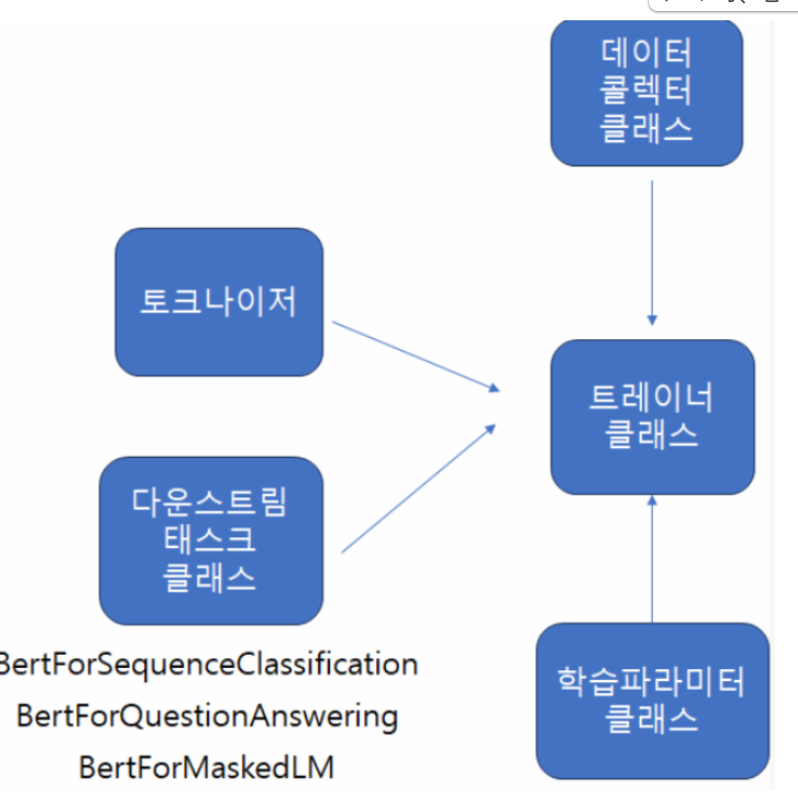

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

# 토큰 결과에 패딩 수행
data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

In [ ]:
# 학습 파라미터 설정
training_args = TrainingArguments(
    # 모델 저장 폴더, 훈련된 모델을 어느 폴더에 저장할지
    output_dir='./results/kobert_naver', # 모델이 달라지면 경로 변경
    # 학습률
    learning_rate=2e-5,
    # 학습률 감쇄 -> 과적합 방지를 위한 weight 패널티
    weight_decay=0.01,
    # 훈련/검증 데이터 배치 사이즈
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    # 학습 반복 수
    num_train_epochs=1,
    # 검증/저장 시기,주기
    eval_strategy="epoch",
    # 매 에폭마다 모델을 저장함.
    save_strategy="epoch",
    # 베스트 모델 저장 여부
    load_best_model_at_end=True
)

In [ ]:
# 위에서 준비한 4가지 객체를 묶어 학습
trainer = Trainer(model = model,                  # 모델
                  args = training_args,             # 학습가중치
                  train_dataset = train_dataset,     # 학습용 데이터
                  eval_dataset = val_dataset,        # 검증 데이터
                  data_collator = data_collator   # 데이터 콜래터
                  )

In [ ]:
# 학습
trainer.train()

In [ ]:
from transformers import AutoTokenizer
import torch
# 드라이브에 저장한 모델 불러와서 새로운 리뷰 확인 (0 부정, 1 긍정)
model = AutoModelForSequenceClassification.from_pretrained("./results/kobert_naver/checkpoint-7500/")
tokenizer = AutoTokenizer.from_pretrained("./results/kobert_naver/checkpoint-7500/")

text = "판매자님의 양심은 어디에 있습니까?"

inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

logits = outputs.logits
pred = torch.argmax(logits, dim=1).item()

print(pred)  # 0 or 1

- 데이터 일부만 추출하여 학습

In [ ]:
%cd /content/drive/MyDrive/00 딥러닝

In [ ]:
import pandas as pd
import pickle
with open('./data/bert_train_data_ratings.pkl', 'rb') as f :
  train_data = pickle.load(f)

In [ ]:
# 데이터 일부분 추출
train_data2 = pd.concat([train_data[:10000], train_data[-10000:]])

In [ ]:
train_data2.shape

- 훈련용 검증용 데이터 분리(train_test_split)
  - 8 : 2
- 문제와 정답으로 분리 -> 리스트로 변환
- Dataset 자료형으로 변경

In [ ]:
from sklearn.model_selection import train_test_split

train_df2, val_df2 = train_test_split(
    train_data2,
    test_size = 0.2,
    random_state = 27
)


train_text2 = train_df2['document'].astype(str).tolist() # pandas.Series -> python.list
train_labels2 = train_df2['label'].tolist() # pandas.Series -> python.list
val_text2 = val_df2['document'].astype(str).tolist()
val_labels2 = val_df2['label'].tolist()


# HuggingFace 학습을 위한 데이터타입 변경 (Dataset)
from datasets import Dataset
train_dataset2 = Dataset.from_dict({'document': train_text2,
                                  'label': train_labels2})
val_dataset2 = Dataset.from_dict({'document': val_text2,
                                  'label': val_labels2})

In [ ]:
train_dataset2

### KoELECTRA
- Bert와 비교했을 때 조금 더 좋은 성능을 보이는 모델
- Transformers 라이브러리를 통하여 간단하게 사용 가능

##### 분석 순서
1. 토큰화 도구 생성(모델에 맞는 토큰화 도구 사용)
  - AutoTokenizer 도구 사용
  - checkpoint : monologg/koelectra-small-v2-discriminator
2. 모델 불러오기
  - AutoModelForSequenceClassification
3. DataCollator
4. TrainingArguments
5. Trainer 객체 생성 후 학습

##### - 리뷰 넣어 예측

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "monologg/koelectra-small-v2-discriminator"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenizer_function (example) :
  return tokenizer(example['document'],     # 데이터셋
                   max_length = 128,        # 문장의 최대 길이(한 개의 리뷰)
                   padding = 'max_length',  # 최대 길이보다 짧을 경우 -> 0값으로 패딩
                   truncation = True)       # 최대 길이보다 길 경우 -> 자르기

train_dataset2 = train_dataset2.map(tokenizer_function, batched = True)
val_dataset2 = val_dataset2.map(tokenizer_function, batched = True)

model2 = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels = 2)

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

# 토큰 결과에 패딩 수행
data_collator2 = DataCollatorWithPadding(tokenizer = tokenizer)

# 학습 파라미터 설정
training_args2 = TrainingArguments(
    # 모델 저장 폴더, 훈련된 모델을 어느 폴더에 저장할지
    output_dir='./results/koelectra_naver', # 모델이 달라지면 경로 변경
    # 학습률
    learning_rate=2e-5,
    # 학습률 감쇄 -> 과적합 방지를 위한 weight 패널티
    weight_decay=0.01,
    # 훈련/검증 데이터 배치 사이즈
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    # 학습 반복 수
    num_train_epochs=1,
    # 검증/저장 시기,주기
    eval_strategy="epoch",
    # 매 에폭마다 모델을 저장함.
    save_strategy="epoch",
    # 베스트 모델 저장 여부
    load_best_model_at_end=True
)

# 위에서 준비한 4가지 객체를 묶어 학습
trainer = Trainer(model = model2,                  # 모델
                  args = training_args2,             # 학습가중치
                  train_dataset = train_dataset2,     # 학습용 데이터
                  eval_dataset = val_dataset2,        # 검증 데이터
                  data_collator = data_collator2   # 데이터 콜래터
                  )

trainer.train()

In [ ]:
from transformers import AutoTokenizer
import torch
# 드라이브에 저장한 모델 불러와서 새로운 리뷰 확인 (0 부정, 1 긍정)
model = AutoModelForSequenceClassification.from_pretrained("./results/koelectra_naver/checkpoint-1000/")
tokenizer = AutoTokenizer.from_pretrained("./results/koelectra_naver/checkpoint-1000/")

text = "상품이 마음에 안 들어요"

inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

logits = outputs.logits
pred = torch.argmax(logits, dim=1).item()

print(pred)  # 0 or 1

### 로컬에 저장한 모델을 사용한 예측의 장점
- 인터넷이 없는 환경에서도 사용 가능(ex. 군부대, 폐쇄망)
- 사전학습된 모델을 커스터마이징하여 저장 후 재사용
- huggingface 업로드 과정 없이 파이프라인, 예측 모두 가능

-> huggingface에 우리가 학습한 모델을 업로드